## Theory

Quadratic Regression is a supervised machine learning technique used to model nonlinear relationships between an independent variable x and a dependent variable y. Unlike linear regression, which fits a straight line, quadratic regression fits a parabolic curve represented by:

y=ax
2
+bx+c

where:

a = coefficient of the quadratic term
b = coefficient of the linear term
c = bias/intercept

In this experiment, PyTorch is used to build a custom regression model. The model parameters are defined using nn.Parameter, allowing PyTorch's automatic differentiation system (Autograd) to compute gradients during training.

The dataset is divided into training and testing sets. The model predictions are compared with actual values using the Mean Absolute Error (MAE) loss function (nn.L1Loss). The optimizer used is Stochastic Gradient Descent (SGD), which updates the model parameters iteratively to minimize prediction error.

The training process consists of:

Forward propagation to generate predictions.
Loss computation.
Backpropagation to calculate gradients.
Parameter updates using SGD.
Repeating the process for multiple epochs until the loss converges.

In [441]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [442]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Quadratic regression for second data set


In [443]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [444]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


In [445]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

In [446]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

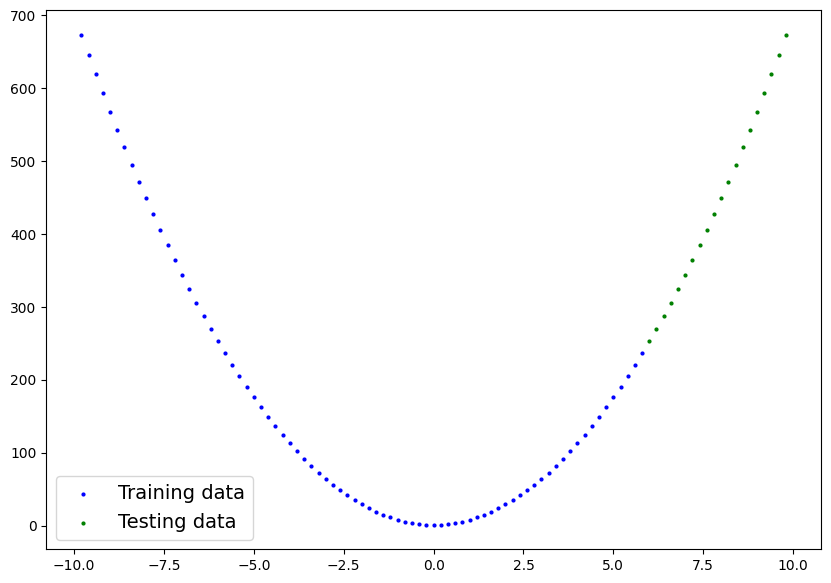

In [447]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)


In [448]:
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        
        # Weight for the x^2 term (a)
        self.weight_quad = nn.Parameter(torch.randn(1, 
                                        dtype=torch.float), 
                                        requires_grad=True)
        
        # Weight for the x term (b)
        self.weight_linear = nn.Parameter(torch.randn(1, 
                                          dtype=torch.float), 
                                          requires_grad=True)
        self.weights=[self.weight_linear,self.weight_quad]
        # Bias term (c)
        self.bias = nn.Parameter(torch.randn(1, 
                                 dtype=torch.float), 
                                 requires_grad=True)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # This is the quadratic formula: y = a*(x^2) + b*x + c
        return self.weight_quad * (x ** 2) + self.weight_linear * x + self.bias

In [449]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = QuadraticRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [450]:

print(model_0.bias.dtype)

torch.float32


In [451]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789]])

In [452]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789],
        [17.6340],
        [18.6159],
        [19.6248],
        [20.6606],
        [21.7234],
        [22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


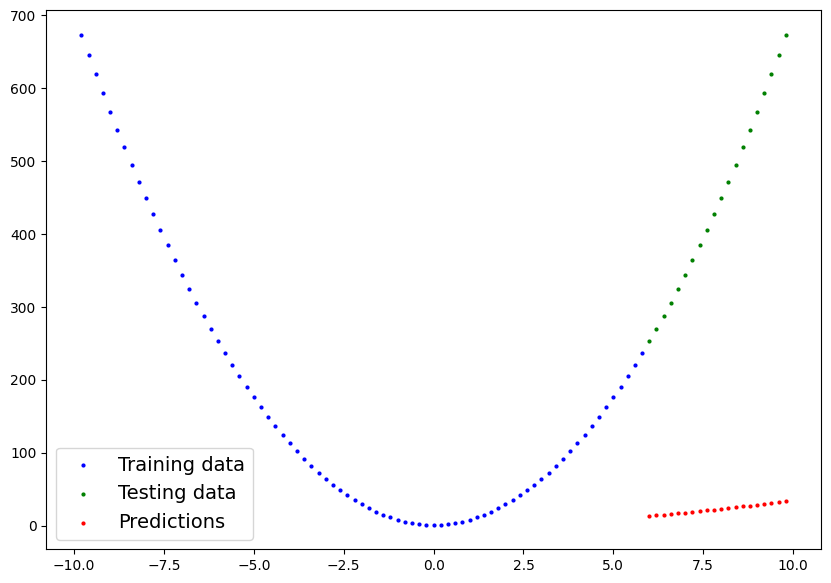

In [453]:
plot_predictions(predictions=y_preds)

In [454]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [455]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 80

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.2732391357422 | MAE Test Loss: 408.8077697753906 
Epoch: 10 | MAE Train Loss: 104.26924896240234 | MAE Test Loss: 252.2126007080078 
Epoch: 20 | MAE Train Loss: 42.265235900878906 | MAE Test Loss: 95.61738586425781 
Epoch: 30 | MAE Train Loss: 2.1109044551849365 | MAE Test Loss: 6.325655937194824 
Epoch: 40 | MAE Train Loss: 1.2364046573638916 | MAE Test Loss: 8.994148254394531 
Epoch: 50 | MAE Train Loss: 1.0613176822662354 | MAE Test Loss: 9.8119478225708 
Epoch: 60 | MAE Train Loss: 1.1207554340362549 | MAE Test Loss: 10.009692192077637 
Epoch: 70 | MAE Train Loss: 0.8819864988327026 | MAE Test Loss: 10.844189643859863 


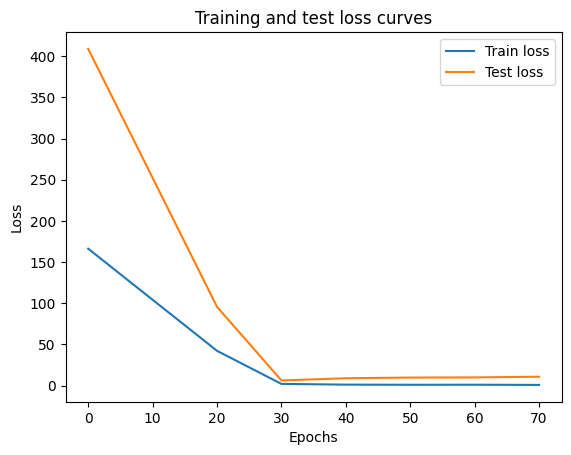

In [456]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [457]:

# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weight_quad': tensor([6.9595]), 'weight_linear': tensor([-0.2252]), 'bias': tensor([0.6074])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


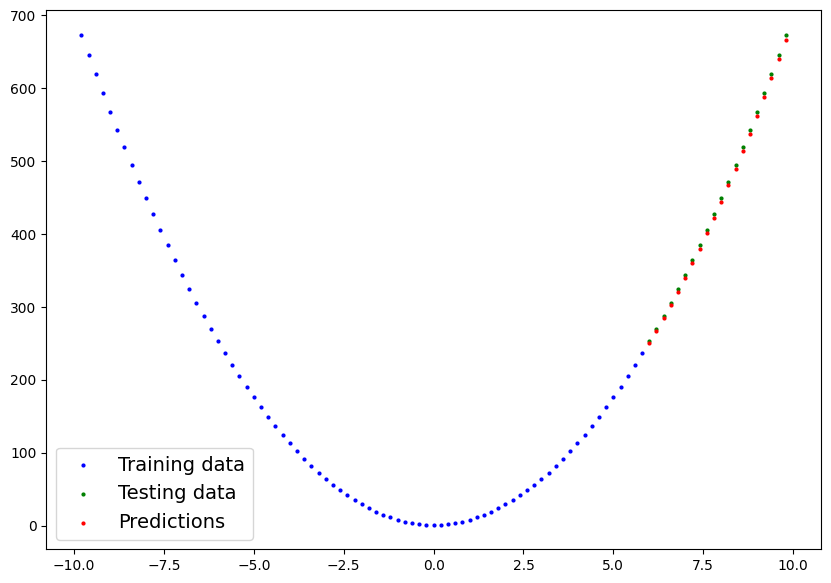

In [458]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

# Linear regression for first dataset


In [459]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


## Discussion

**Discussion** This experiment shows how we can use PyTorch to make a model that learns in a -linear way using a simple quadratic equation. When we first start training the model it makes mistakes because its settings are random.. As training continues the model gets better and better at guessing by changing its settings like the quadratic part, the linear part and where it starts.

The. Errors, that the model makes on the training and testing data get smaller and smaller over time. This means the model is getting better at predicting what the output will be. The fact that the losses decrease shows that the model is learning from the data and getting closer to making predictions.

When we evaluate the model we use `torch.inference_mode()` to make predictions faster and use memory. After training the models settings match the data well so its predictions are close to the values.

This experiment also helps us understand some ideas in machine learning like:

* How to prepare data and convert it into a format the model can use.

* How to split data into parts for training and testing.

* How to make custom models using `nn.Module`.

* How to choose the way to measure the models error for regression tasks.

* How to improve the models settings using descent.

* How to check how well the model is doing and show the results.

In conclusion this lab gives us hands-on experience, with making, training and evaluating a regression model in PyTorch. It covers the process of machine learning from handling data and making the model to improving it and checking how well it works.

## Conclusion

**Conclusion** This experiment showed that we can create a model using PyTorch to find a curved relationship between input and target variables. We used a way to improve the model called Stochastic Gradient Descent (SGD) and a way to measure mistakes called Mean Absolute Error (MAE).

The model got better and better at making predictions as it trained. This was because we adjusted the model settings to make mistakes. After some training the model made a curve that matched the data well.

The model made predictions in the end. This means it learned the relationship in the data.

The lab was helpful because it let us try out machine learning ideas. These included making our model improving it and checking how well it works. We also used Autograd to compute gradients

Overall working on this project gave us experience, with creating, training and testing regression models using PyTorch. The PyTorch model worked well. We used PyTorch to make the model. The model used PyTorch to make predictions.